In [30]:
import os
import glob
import fnmatch
import struct
import numpy as np
import collections
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import cv2

In [2]:
dat_files = []
for root, dirnames, filenames in os.walk('/content'):
    for filename in fnmatch.filter(filenames, '*.dat'):
        dat_files.append(os.path.join(root, filename))

if dat_files:
    print('Found .dat files:')
    for f in dat_files:
        print(f)
else:
    print('No .dat files found.')

Found .dat files:
/content/user6-6-1-2-2-r1.dat
/content/user6-5-4-1-5-r1.dat
/content/user6-3-2-2-2-r1.dat
/content/user6-4-5-3-4-r1.dat
/content/user6-3-5-2-2-r1.dat
/content/user6-3-4-1-3-r1.dat
/content/user6-6-2-5-4-r1.dat
/content/user6-2-1-5-3-r1.dat
/content/user6-4-2-2-2-r1.dat
/content/user6-4-1-1-5-r1.dat
/content/user6-1-2-1-4-r1.dat
/content/user6-6-5-2-4-r1.dat
/content/user6-3-1-5-2-r1.dat
/content/user6-6-5-5-3-r1.dat
/content/user6-3-2-4-5-r1.dat
/content/user6-3-2-5-5-r1.dat
/content/user6-5-5-3-3-r1.dat
/content/user6-5-5-2-5-r1.dat
/content/user6-1-2-2-3-r1.dat
/content/user6-6-4-2-4-r1.dat
/content/user6-1-4-4-1-r1.dat
/content/user6-2-4-1-3-r1.dat
/content/user6-5-4-4-2-r1.dat
/content/user6-4-2-5-3-r1.dat
/content/user6-1-3-5-4-r1.dat
/content/user6-1-5-3-4-r1.dat
/content/user6-4-3-1-5-r1.dat
/content/user6-6-2-1-1-r1.dat
/content/user6-1-2-4-5-r1.dat
/content/user6-4-4-1-4-r1.dat
/content/user6-4-4-2-5-r1.dat
/content/user6-6-5-3-3-r1.dat
/content/user6-5-2-5-3

In [8]:
class filter:
  def apply_butterworth_filter(self,csi_amplitude, lowcut=2.0, highcut=20.0, fs=100.0, order=5):
      nyq = 0.5 * fs
      low = lowcut / nyq
      high = highcut / nyq
      b, a = butter(order, [low, high], btype='band')

      filtered_csi = np.zeros_like(csi_amplitude)

      n_tx, n_rx, n_sub = csi_amplitude.shape[1], csi_amplitude.shape[2], csi_amplitude.shape[3]

      for tx in range(n_tx):
          for rx in range(n_rx):
              for sub in range(n_sub):
                  signal = csi_amplitude[:, tx, rx, sub]
                  if len(signal) > 3 * order:
                      filtered_csi[:, tx, rx, sub] = filtfilt(b, a, signal)
                  else:
                      filtered_csi[:, tx, rx, sub] = signal

      return filtered_csi


In [9]:
class Widar30Diagnostics_fourth:
  def __init__(self,filter):
    self.filter = filter();
  def batch_process_widar_directory(self,directory_path):
      file_pattern = os.path.join(directory_path, "*.dat")
      dat_files = glob.glob(file_pattern)

      print(f"Found {len(dat_files)} .dat files to process in directory.")

      processed_dataset_collection = {}

      for file_path in dat_files:
          file_name = os.path.basename(file_path)
          print(f"\nProcessing file: {file_name}")
          with open(file_path, "rb") as f:
              raw_data = f.read()

          total_bytes = len(raw_data)
          if total_bytes < 4:
              print(f"Skipping {file_name}: File empty or corrupted.")
              continue

          initial_payload_len = struct.unpack(">H", raw_data[0:2])[0]
          dynamic_packet_size = initial_payload_len + 2

          first_packet = raw_data[0:dynamic_packet_size]
          raw_n_rx = first_packet[10]
          raw_n_tx = first_packet[11]
          num_subcarriers = 30

          if raw_n_rx == 0 or raw_n_rx > 4:
              if raw_n_tx == 3:
                  dynamic_n_tx, dynamic_n_rx = 1, 3
              else:
                  dynamic_n_tx, dynamic_n_rx = 1, 3
          else:
              dynamic_n_tx, dynamic_n_rx = raw_n_tx, raw_n_rx

          num_packets = total_bytes // dynamic_packet_size
          csi_frames = []

          for i in range(num_packets):
              start_idx = i * dynamic_packet_size
              packet = raw_data[start_idx : start_idx + dynamic_packet_size]

              if packet[2] != 187:
                  continue

              csi_payload = packet[25:]
              csi_matrix = np.zeros((dynamic_n_tx, dynamic_n_rx, num_subcarriers), dtype=complex)
              bit_index = 0

              for tx_idx in range(dynamic_n_tx):
                  for rx_idx in range(dynamic_n_rx):
                      for sub_idx in range(num_subcarriers):
                          try:
                              byte_idx = bit_index // 8
                              bit_rem = bit_index % 8
                              b1 = csi_payload[byte_idx]
                              b2 = csi_payload[byte_idx + 1]
                              imag = ((b1 >> bit_rem) | (b2 << (8 - bit_rem))) & 0x03FF
                              if imag >= 512: imag -= 1024

                              bit_index += 10
                              byte_idx = bit_index // 8
                              bit_rem = bit_index % 8
                              b1 = csi_payload[byte_idx]
                              b2 = csi_payload[byte_idx + 1]
                              real = ((b1 >> bit_rem) | (b2 << (8 - bit_rem))) & 0x03FF
                              if real >= 512: real -= 1024

                              bit_index += 10
                              csi_matrix[tx_idx, rx_idx, sub_idx] = complex(real, imag)
                          except IndexError:
                              break
              csi_frames.append(csi_matrix)

          csi_array = np.array(csi_frames)
          if len(csi_array) == 0:
              print(f"Skipping {file_name}: 0 valid frames parsed.")
              continue

          amplitude_data = np.abs(csi_array)
          filtered_data = self.filter.apply_butterworth_filter(amplitude_data, lowcut=2.0, highcut=20.0, fs=100.0)
          flattened_features = filtered_data.reshape(filtered_data.shape[0], -1)
          denom = flattened_features.max() - flattened_features.min()
          if denom == 0: denom = 1.0
          normalized_features = (flattened_features - flattened_features.min()) / denom
          processed_dataset_collection[file_name] = normalized_features
          print(f"Successfully processed {file_name}! Final Shape: {normalized_features.shape}")

      return processed_dataset_collection


In [11]:
target_directory = "."
wider_fourth = Widar30Diagnostics_fourth(filter)
all_training_data = wider_fourth.batch_process_widar_directory(target_directory)

Found 750 .dat files to process in directory.

Processing file: user6-6-1-2-2-r1.dat
Successfully processed user6-6-1-2-2-r1.dat! Final Shape: (1231, 90)

Processing file: user6-5-4-1-5-r1.dat
Successfully processed user6-5-4-1-5-r1.dat! Final Shape: (1346, 90)

Processing file: user6-3-2-2-2-r1.dat
Successfully processed user6-3-2-2-2-r1.dat! Final Shape: (884, 90)

Processing file: user6-4-5-3-4-r1.dat
Successfully processed user6-4-5-3-4-r1.dat! Final Shape: (1314, 90)

Processing file: user6-3-5-2-2-r1.dat
Successfully processed user6-3-5-2-2-r1.dat! Final Shape: (1000, 90)

Processing file: user6-3-4-1-3-r1.dat
Successfully processed user6-3-4-1-3-r1.dat! Final Shape: (923, 90)

Processing file: user6-6-2-5-4-r1.dat
Successfully processed user6-6-2-5-4-r1.dat! Final Shape: (1190, 90)

Processing file: user6-2-1-5-3-r1.dat
Successfully processed user6-2-1-5-3-r1.dat! Final Shape: (1248, 90)

Processing file: user6-4-2-2-2-r1.dat
Successfully processed user6-4-2-2-2-r1.dat! Final Sh

In [12]:
class CSIConditionalGenerator(nn.Module):
    def __init__(self, noise_dim=100, condition_dim=90, img_channels=1):
        super(CSIConditionalGenerator, self).__init__()
        self.input_dim = noise_dim + condition_dim

        self.model = nn.Sequential(
            nn.ConvTranspose2d(self.input_dim, 256, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, condition):
        x = torch.cat([noise, condition], dim=1)
        return self.model(x)

class CSIConditionalDiscriminator(nn.Module):
    def __init__(self, img_channels=1, condition_dim=90):
        super(CSIConditionalDiscriminator, self).__init__()
        self.condition_dim = condition_dim
        self.image_proc = nn.Sequential(
            nn.Conv2d(img_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.evaluator = nn.Sequential(
            nn.Conv2d(64 + condition_dim, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, img, condition):
        img_features = self.image_proc(img)
        spatial_condition = condition.repeat(1, 1, img_features.size(2), img_features.size(3))
        combined = torch.cat([img_features, spatial_condition], dim=1)
        return self.evaluator(combined)

noise_dim = 100
condition_dim = 90
img_channels = 1
netG = CSIConditionalGenerator(noise_dim, condition_dim, img_channels)
netD = CSIConditionalDiscriminator(img_channels, condition_dim)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))

print("Conditional GAN networks successfully initialised and compiled.")


Conditional GAN networks successfully initialised and compiled.


In [13]:
def train_gan_step(real_images, csi_conditions, batch_size):
    csi_conditions_4d = csi_conditions.view(batch_size, 90, 1, 1)
    label_real = torch.ones(batch_size, 1, 1, 1)
    label_fake = torch.zeros(batch_size, 1, 1, 1)
    optimizer_D.zero_grad()
    output_real = netD(real_images, csi_conditions_4d)
    loss_D_real = criterion(output_real, label_real)

    noise = torch.randn(batch_size, noise_dim, 1, 1)
    fake_images = netG(noise, csi_conditions_4d)

    output_fake = netD(fake_images.detach(), csi_conditions_4d)
    loss_D_fake = criterion(output_fake, label_fake)

    loss_D = loss_D_real + loss_D_fake
    loss_D.backward()
    optimizer_D.step()

    optimizer_G.zero_grad()
    output_g_fake = netD(fake_images, csi_conditions_4d)
    loss_G = criterion(output_g_fake, label_real)

    loss_G.backward()
    optimizer_G.step()

    return loss_D.item(), loss_G.item()


In [14]:
def generate_synthetic_room_label(room_id, position_id, img_size=64):
    """
    This function generates structured ground truth image arrays for Widar 3.0:
    room_id: 1 (Classroom), 2 (Hall), 3 (Office)
    position_id: 1, 2, 3, 4, 5 (User locations inside the grey zones taken ref from pdf)
    """
    canvas = np.full((img_size, img_size), -1.0, dtype=np.float32)

    if room_id == 1:
        canvas[int(img_size*0.08):int(img_size*0.52), int(img_size*0.12):int(img_size*0.88)] = -0.4
        canvas[int(img_size*0.85):int(img_size*0.93), int(img_size*0.28):int(img_size*0.72)] = -0.2
        sa_t, sa_b, sa_l, sa_r = int(img_size*0.55), int(img_size*0.82), int(img_size*0.24), int(img_size*0.76)
    elif room_id == 2:
        canvas[0:int(img_size*0.15), :] = -0.6
        canvas[int(img_size*0.65):int(img_size*0.72), :] = -0.6
        canvas[int(img_size*0.72):, int(img_size*0.18):int(img_size*0.38)] = -0.3
        canvas[int(img_size*0.72):, int(img_size*0.62):int(img_size*0.82)] = -0.3
        sa_t, sa_b, sa_l, sa_r = int(img_size*0.22), int(img_size*0.58), int(img_size*0.25), int(img_size*0.75)
    elif room_id == 3:
        canvas[0:2, :] = -0.6; canvas[-2:, :] = -0.6
        canvas[:, 0:2] = -0.6; canvas[:, -2:] = -0.6
        canvas[int(img_size*0.40):int(img_size*0.72), int(img_size*0.06):int(img_size*0.32)] = -0.2
        canvas[int(img_size*0.85):int(img_size*0.94), int(img_size*0.45):int(img_size*0.75)] = -0.4
        sa_t, sa_b, sa_l, sa_r = int(img_size*0.18), int(img_size*0.82), int(img_size*0.38), int(img_size*0.85)

    else:
        raise ValueError("Invalid Room ID specified. Choose 1, 2, or 3.")

    canvas[sa_t:sa_b, sa_l:sa_r] = 0.0
    cx, cy = (sa_l + sa_r) // 2, (sa_t + sa_b) // 2
    w_q, h_q = (sa_r - sa_l) // 4, (sa_b - sa_t) // 4
    grid_map = {
        1: (cx - w_q, cy - h_q),
        2: (cx + w_q, cy - h_q),
        3: (cx, cy),
        4: (cx - w_q, cy + h_q),
        5: (cx + w_q, cy + h_q)
    }

    px, py = grid_map.get(position_id, (cx, cy))
    radius = max(1, img_size // 32)
    canvas[py-radius:py+radius+1, px-radius:px+radius+1] = 1.0

    return canvas


In [24]:
synthetic_room1_1 = generate_synthetic_room_label(1, 1)
synthetic_room1_2 = generate_synthetic_room_label(1, 2)
synthetic_room1_3 = generate_synthetic_room_label(1, 3)
synthetic_room1_4 = generate_synthetic_room_label(1, 4)
synthetic_room1_5 = generate_synthetic_room_label(1, 5)

In [25]:
all_csi_feature_room1 = np.random.rand(1452, 90)
canvas_labels = []
available_room_labels = [
    synthetic_room1_1,
    synthetic_room1_2,
    synthetic_room1_3,
    synthetic_room1_4,
    synthetic_room1_5
]
for _ in range(all_csi_feature_room1.shape[0]):
    selected_label_2d = available_room_labels[np.random.randint(0, len(available_room_labels))]
    canvas_labels.append(selected_label_2d[np.newaxis, :, :])

canvas_labels = np.array(canvas_labels)
print(f"Shape of generated canvas_labels: {canvas_labels.shape}")

Shape of generated canvas_labels: (1452, 1, 64, 64)


In [26]:
class DynamicWidarDataset(Dataset):
    def __init__(self, csi_data, image_labels):
        self.x = torch.tensor(csi_data, dtype=torch.float32)
        self.y = torch.tensor(image_labels, dtype=torch.float32)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [27]:
gan_dataset = DynamicWidarDataset(all_csi_feature_room1, canvas_labels)
gan_dataloader = DataLoader(gan_dataset, batch_size=32, shuffle=True)

print("Pipeline established! Batches are ready for your GAN model layers.")

Pipeline established! Batches are ready for your GAN model layers.


Starting GAN pipeline processing model layers...

Epoch [1/50] | Loss D: 0.4491 | Loss G: 3.3218


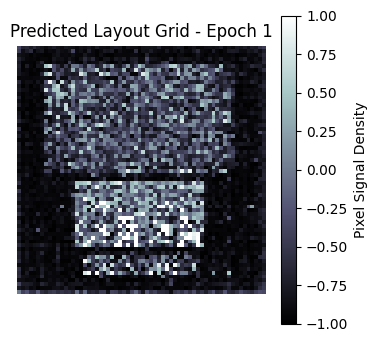

Epoch [2/50] | Loss D: 0.5699 | Loss G: 3.3611


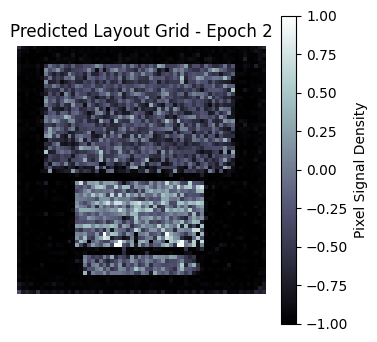

Epoch [4/50] | Loss D: 1.2658 | Loss G: 1.0218


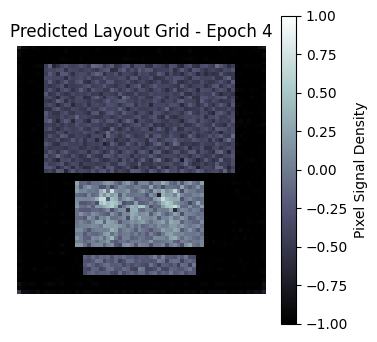

Epoch [6/50] | Loss D: 1.0315 | Loss G: 1.5351


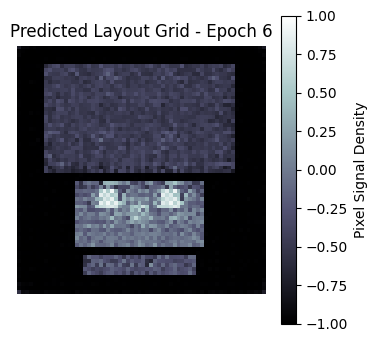

Epoch [8/50] | Loss D: 0.7701 | Loss G: 1.8883


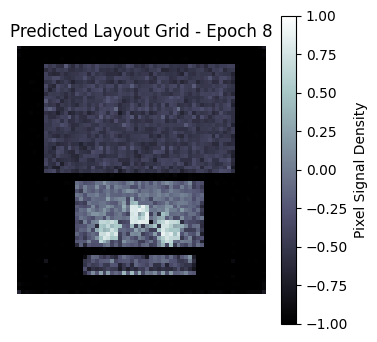

Epoch [10/50] | Loss D: 0.4344 | Loss G: 2.7225


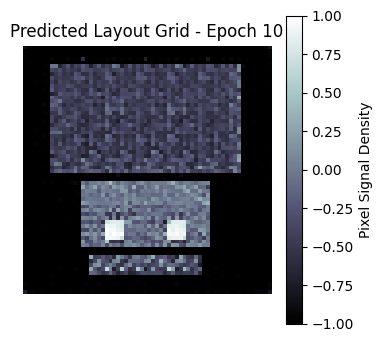

Epoch [12/50] | Loss D: 0.3926 | Loss G: 3.0668


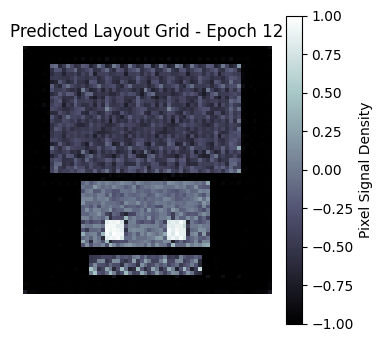

Epoch [14/50] | Loss D: 0.4179 | Loss G: 2.7919


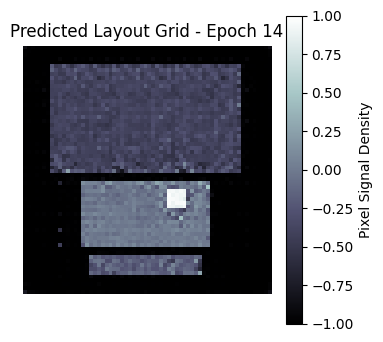

Epoch [16/50] | Loss D: 0.2460 | Loss G: 3.0510


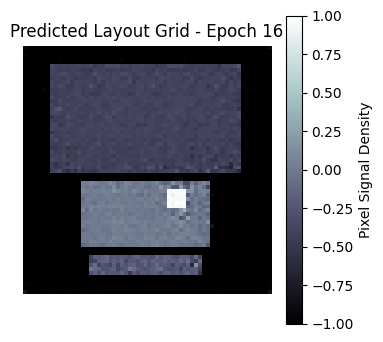

Epoch [18/50] | Loss D: 0.1245 | Loss G: 3.7185


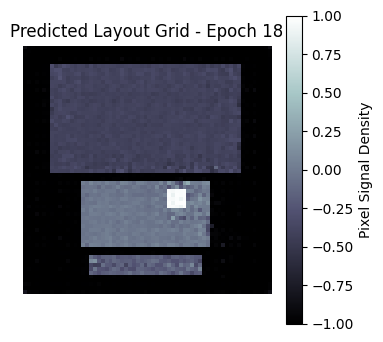

Epoch [20/50] | Loss D: 0.1233 | Loss G: 4.3128


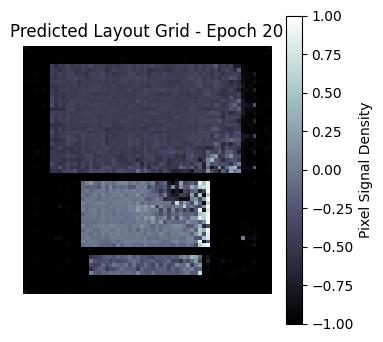

Epoch [22/50] | Loss D: 0.4559 | Loss G: 3.0553


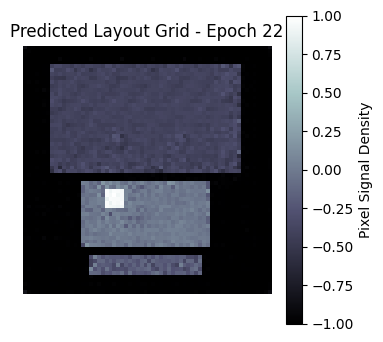

Epoch [24/50] | Loss D: 0.1153 | Loss G: 3.4725


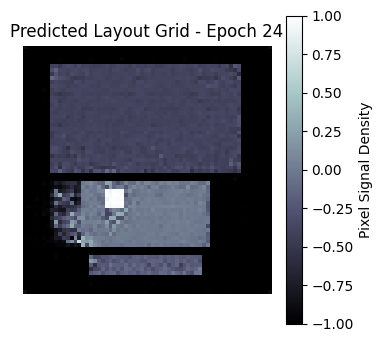

Epoch [26/50] | Loss D: 0.0491 | Loss G: 4.3451


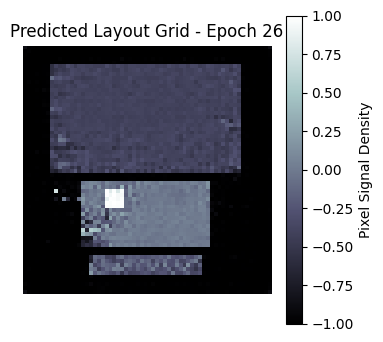

Epoch [28/50] | Loss D: 0.2708 | Loss G: 3.4597


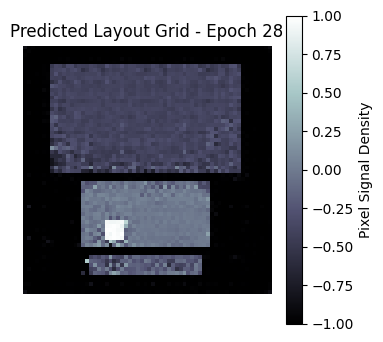

Epoch [30/50] | Loss D: 0.0661 | Loss G: 4.1044


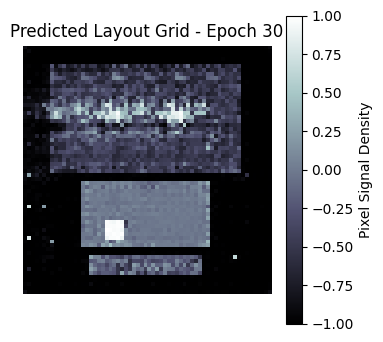

Epoch [32/50] | Loss D: 0.4811 | Loss G: 3.7431


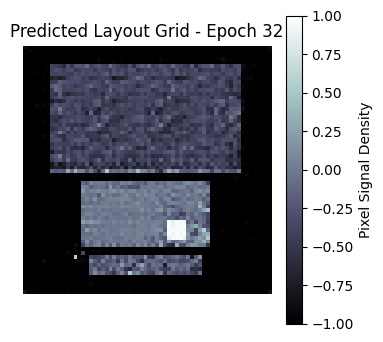

Epoch [34/50] | Loss D: 0.1081 | Loss G: 3.6269


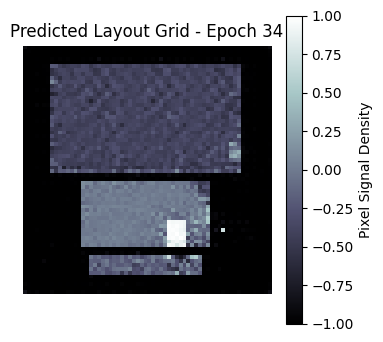

Epoch [36/50] | Loss D: 0.1865 | Loss G: 3.8378


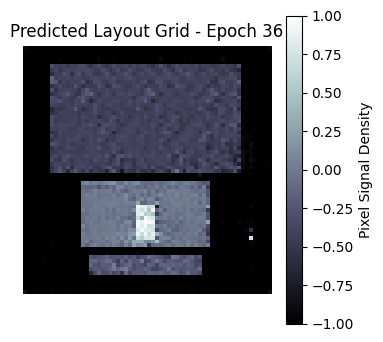

Epoch [38/50] | Loss D: 0.0232 | Loss G: 5.1025


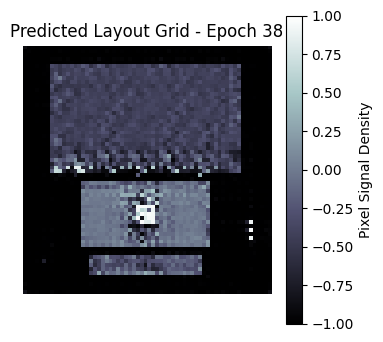

Epoch [40/50] | Loss D: 0.1358 | Loss G: 5.5181


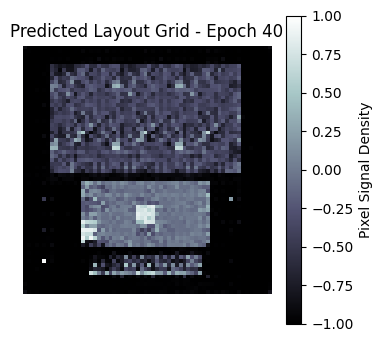

Epoch [42/50] | Loss D: 0.0079 | Loss G: 5.8135


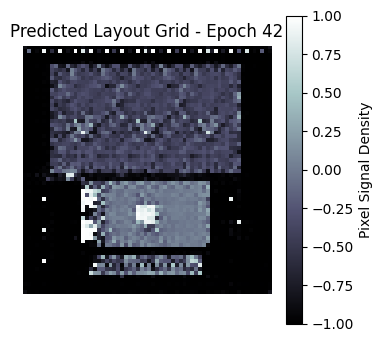

Epoch [44/50] | Loss D: 0.0186 | Loss G: 5.7094


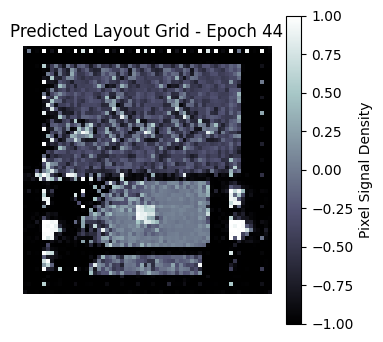

Epoch [46/50] | Loss D: 0.0142 | Loss G: 5.4066


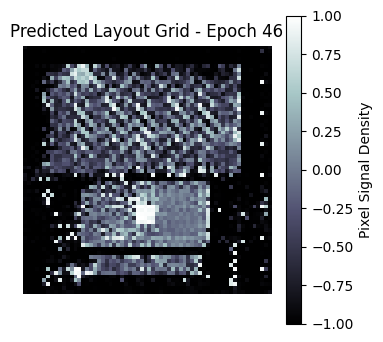

Epoch [48/50] | Loss D: 0.4096 | Loss G: 7.8775


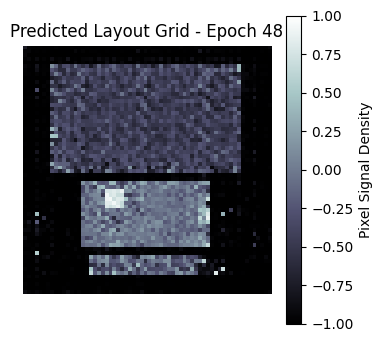

Epoch [50/50] | Loss D: 0.1203 | Loss G: 4.6904


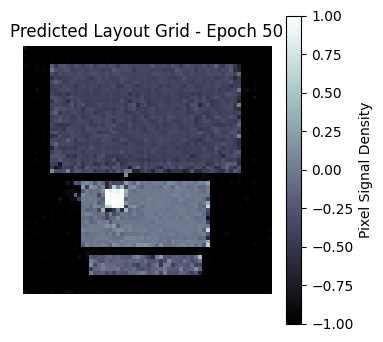


GAN training loop successfully completed!


In [29]:
class CSIGenerator(nn.Module):
    def __init__(self, noise_dim=100, condition_dim=90):
        super(CSIGenerator, self).__init__()
        self.input_dim = noise_dim + condition_dim
        self.model = nn.Sequential(
            nn.ConvTranspose2d(self.input_dim, 256, kernel_size=4, stride=1, padding=0, bias=False), # Output: 256x4x4
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False), # Output: 128x8x8
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False), # Output: 64x16x16
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, bias=False), # Output: 32x32x32
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1, bias=False),  # Output: 1x64x64
            nn.Tanh()
        )
    def forward(self, noise, condition):
        x = torch.cat([noise, condition], dim=1).unsqueeze(-1).unsqueeze(-1) # Add spatial dimensions for ConvTranspose2d
        return self.model(x)

class CSIDiscriminator(nn.Module):
    def __init__(self, condition_dim=90):
        super(CSIDiscriminator, self).__init__()
        self.img_proc = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.evaluator = nn.Sequential(
            nn.Conv2d(32 + condition_dim, 128, kernel_size=4, stride=2, padding=1, bias=False), # Output: 128x16x16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, kernel_size=8, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, img, condition):
        img_feats = self.img_proc(img)
        spatial_condition = condition.repeat(1, 1, img_feats.size(2), img_feats.size(3))
        combined = torch.cat([img_feats, spatial_condition], dim=1)
        return self.evaluator(combined)

def predict_and_plot(generator_model, single_csi_condition, epoch_num):
    generator_model.eval()
    with torch.no_grad():
        test_condition = torch.tensor(single_csi_condition, dtype=torch.float32).view(1, 90)
        test_noise = torch.randn(1, 100)
        generated_tensor = generator_model(test_noise, test_condition)
        generated_image = generated_tensor.squeeze().cpu().numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(generated_image, cmap='bone', vmin=-1.0, vmax=1.0)
    plt.title(f"Predicted Layout Grid - Epoch {epoch_num}")
    plt.axis('off')
    plt.colorbar(label="Pixel Signal Density")
    plt.show()
    generator_model.train()

dataset = gan_dataset
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

noise_dim = 100
netG = CSIGenerator(noise_dim=noise_dim, condition_dim=condition_dim)
netD = CSIDiscriminator(condition_dim=condition_dim)
criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))

num_epochs = 50
print("Starting GAN pipeline processing model layers...\n")

for epoch in range(1, num_epochs + 1):
    loss_d_accum, loss_g_accum = 0.0, 0.0

    for csi_signals, real_imgs in dataloader:
        b_size = csi_signals.size(0)


        cond_4d = csi_signals.view(b_size, 90, 1, 1)
        labels_real = torch.ones(b_size, 1, 1, 1)
        labels_fake = torch.zeros(b_size, 1, 1, 1)
        optimizer_D.zero_grad()
        out_real = netD(real_imgs, cond_4d)
        loss_real = criterion(out_real, labels_real)

        noise = torch.randn(b_size, noise_dim)
        fake_imgs = netG(noise, csi_signals)
        out_fake = netD(fake_imgs.detach(), cond_4d)
        loss_fake = criterion(out_fake, labels_fake)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        optimizer_D.step()
        loss_d_accum += loss_d.item()
        optimizer_G.zero_grad()
        out_g_fake = netD(fake_imgs, cond_4d)
        loss_g = criterion(out_g_fake, labels_real)
        loss_g.backward()
        optimizer_G.step()
        loss_g_accum += loss_g.item()

    if epoch % 2 == 0 or epoch == 1:
        print(f"Epoch [{epoch}/{num_epochs}] | Loss D: {loss_d_accum/len(dataloader):.4f} | Loss G: {loss_g_accum/len(dataloader):.4f}")
        sample_csi_row = all_csi_feature_room1[0]
        predict_and_plot(netG, sample_csi_row, epoch)

print("\nGAN training loop successfully completed!")

In [33]:
torch.save(netG.state_dict(), 'generator_model.pth')
torch.save(netD.state_dict(), 'discriminator_model.pth')
print("GAN models saved successfully!")

GAN models saved successfully!


Using CSI sample from user6-1-2-4-3-r1.dat with shape: (90,)


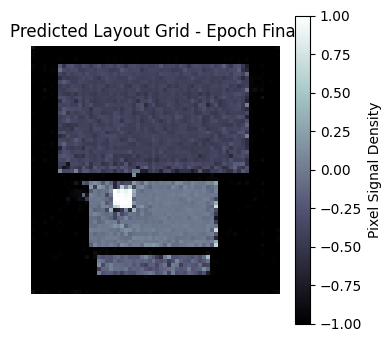

In [43]:
file_to_predict = 'user6-1-2-4-3-r1.dat'
if file_to_predict in all_training_data:
    csi_for_prediction = all_training_data[file_to_predict]
    single_csi_sample_for_plot = csi_for_prediction[0]
    print(f"Using CSI sample from {file_to_predict} with shape: {single_csi_sample_for_plot.shape}")
    predict_and_plot(netG, single_csi_sample_for_plot, epoch_num='Final')
else:
    print(f"Error: File {file_to_predict} not found in processed training data.")